In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
load_dotenv()  # reads ../.env if the noteb

True

In [2]:
# --- fill these in for your local MySQL install ---
MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = os.getenv("MYSQL_PORT")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

In [3]:
engine = create_engine(
        f"mysql+mysqlconnector://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
    )


In [4]:
dim_factories = pd.read_sql("SELECT * FROM dim_factories", engine)
dim_targets = pd.read_sql("SELECT * FROM dim_targets", engine)
dim_products = pd.read_sql("SELECT * FROM dim_products", engine)
dim_geography = pd.read_sql("SELECT * FROM dim_geography", engine)
fact_sales = pd.read_sql("SELECT * FROM fact_sales", engine)

What are the most efficient factory to customer shipping routes?

What are the least efficient factory to customer shipping routes?

Which product lines have the best product margin?

Which product lines should be moved to a different factory to optimize shipping routes?

In [5]:
fact_sales['profit_margin_pct']= round(fact_sales['gross_profit']*100 /fact_sales['sales'], 2 )

In [6]:
sales = fact_sales.merge(dim_products, how='left', left_on=['product_id', 'division'],
                    right_on=['product_id', 'division'])

#### KPIs

In [7]:
print(f"Total Orders : {sales['order_id'].nunique()}")
print(f"Total Revenue : {round(sales['sales'].sum()/1e3, 2)}K $" )
print(f"Total Revenue : {round(sales['gross_profit'].sum()/1e3, 2)}K $" )
print(f"Products : {sales['product_id'].nunique()}")
print(f"Total Customers : {sales['customer_id'].nunique()}")

Total Orders : 8549
Total Revenue : 141.78K $
Total Revenue : 93.44K $
Products : 15
Total Customers : 5044


In [8]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   row_id             10194 non-null  int64  
 1   order_id           10194 non-null  str    
 2   order_date         10194 non-null  object 
 3   ship_date          10194 non-null  object 
 4   ship_mode          10194 non-null  str    
 5   customer_id        10194 non-null  str    
 6   country_region     10194 non-null  str    
 7   city               10194 non-null  str    
 8   state_province     10194 non-null  str    
 9   postal_code        10194 non-null  str    
 10  division           10194 non-null  str    
 11  region             10194 non-null  str    
 12  product_id         10194 non-null  str    
 13  sales              10194 non-null  float64
 14  units              10194 non-null  int64  
 15  gross_profit       10194 non-null  float64
 16  cost               10194 non-null

In [9]:
sales['order_date'] = pd.to_datetime(sales['order_date'])
sales["order_month_year"] = sales['order_date'].dt.strftime("%b-%Y")
sales["order_month_year"] = pd.to_datetime(sales["order_month_year"])

C:\Users\omkarkhare\AppData\Local\Temp\ipykernel_11980\2715093839.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales["order_month_year"] = pd.to_datetime(sales["order_month_year"])


In [10]:
sales_monthwise = sales.groupby('order_month_year').agg(orders = ('order_id', 'nunique'), units = ('units', 'sum'), revenue = ('sales', sum), 
                                                        profit = ("gross_profit", 'sum'), cost = ('cost', "sum"), profit_margin = ('profit_margin_pct', 'mean')).reset_index()
sales_monthwise

,order_month_year,orders,units,revenue,profit,cost,profit_margin
0,2021-01-01,61,306,1065.24,704.00,361.24,65.682619
1,2021-02-01,40,159,547.09,358.07,189.02,65.278478
2,2021-03-01,132,597,2245.63,1425.29,820.34,64.764780
3,2021-04-01,113,536,2058.97,1325.13,733.84,66.737556
4,2021-05-01,118,504,1855.21,1208.23,646.98,65.556439
5,2021-06-01,118,524,1838.43,1218.69,619.74,66.427353
6,2021-07-01,113,550,1908.23,1265.25,642.98,65.648112
7,2021-08-01,131,624,2258.46,1475.44,783.02,65.803924
8,2021-09-01,234,1015,3927.08,2552.90,1374.18,66.656740
9,2021-10-01,138,605,2544.88,1624.84,920.04,66.646845


Text(0.5, 1.0, 'Monthly Oreders trend')

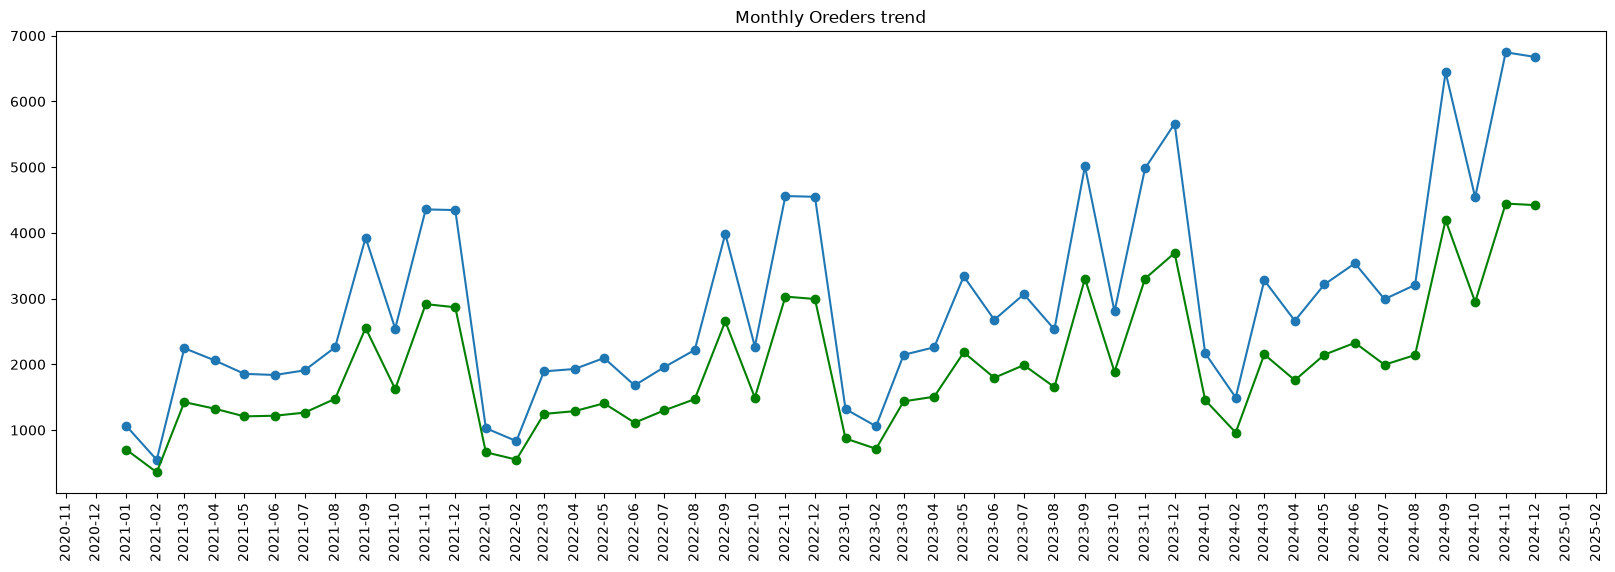

In [11]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(20, 6))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

# 3. Format how the dates look (YYYY-MM to match your image)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 4. Rotate the labels so they don't overlap
plt.xticks(rotation=90)


plt.plot(sales_monthwise['order_month_year'], sales_monthwise['revenue'], marker = 'o')
plt.plot(sales_monthwise['order_month_year'], sales_monthwise['profit'], marker = 'o', color = 'g')

plt.xticks( rotation =90 )
plt.title('Monthly Oreders trend')

In [13]:
sales_product = sales.groupby('product_name').agg(orders = ('order_id', 'nunique'), units = ('units', 'sum'), revenue = ('sales', sum), 
                                                        profit = ("gross_profit", 'sum'), cost = ('cost', "sum"), profit_margin = ('profit_margin_pct', 'mean')).reset_index()
sales_product.sort_values('revenue', ascending=False)

,product_name,orders,units,revenue,profit,cost,profit_margin
11,Wonka Bar - Triple Dazzle Caramel,1677,7596,28485.00,18610.20,9874.80,65.33
12,Wonka Bar -Scrumdiddlyumptious,1704,7743,27874.80,19357.50,8517.30,69.44
9,Wonka Bar - Milk Chocolate,1768,8267,26867.75,17443.37,9424.38,64.92
8,Wonka Bar - Fudge Mallows,1527,6914,24890.40,16593.60,8296.80,66.67
10,Wonka Bar - Nutty Crunch Surprise,1529,6755,23574.95,16819.95,6755.00,71.35
5,Lickable Wallpaper,92,393,7860.00,3930.00,3930.00,50.00
3,Kazookles,94,371,1205.75,92.75,1113.00,7.69
13,Wonka Gum,118,478,597.50,310.70,286.80,52.00
0,Everlasting Gobstopper,3,13,130.00,104.00,26.00,80.00
2,Hair Toffee,4,17,76.50,59.50,17.00,77.78


C:\Users\omkarkhare\AppData\Local\Temp\ipykernel_11980\1391700456.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(sales_product, y = sales_product['profit'], x= sales_product['product_name'], palette='viridis')


Text(0.5, 1.0, 'Profit by Product')

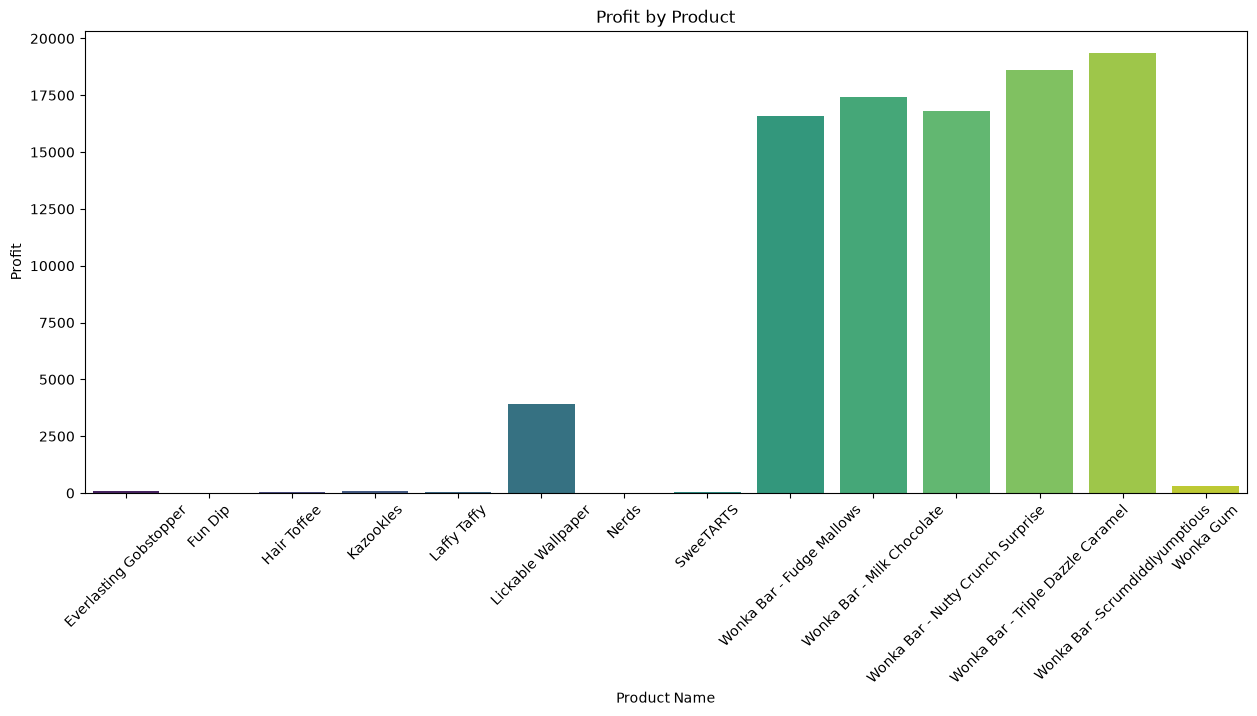

In [17]:
plt.figure(figsize=(15,6))
sns.barplot(sales_product, y = sales_product['profit'], x= sales_product['product_name'], palette='viridis')

plt.xlabel('Product Name')
plt.ylabel('Profit')
plt.xticks(rotation = 45)
plt.title("Profit by Product")

In [19]:
sales_division = sales.groupby('division').agg(orders = ('order_id', 'nunique'), units = ('units', 'sum'), revenue = ('sales', 'sum'), 
                                                        profit = ("gross_profit", 'sum'), cost = ('cost', "sum"), profit_margin = ('profit_margin_pct', 'mean')).reset_index()
sales_division.sort_values('revenue', ascending= False)

,division,orders,units,revenue,profit,cost,profit_margin
0,Chocolate,8205,37275,131692.90,88824.62,42868.28,67.457102
1,Other,304,1242,9663.25,4333.45,5329.80,37.671742
2,Sugar,40,137,427.48,284.73,142.75,57.690000


C:\Users\omkarkhare\AppData\Local\Temp\ipykernel_11980\363019384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(sales_division, y = sales_division['profit'], x= sales_division['division'], palette='cividis')


Text(0.5, 1.0, 'Profit by Division')

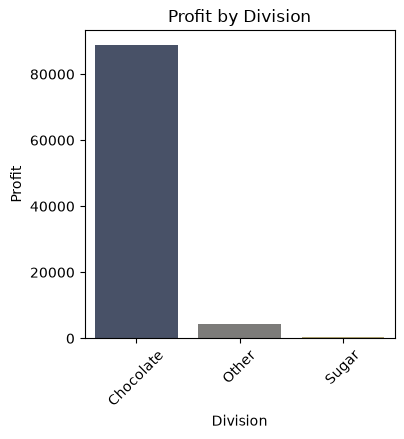

In [21]:
plt.figure(figsize=(4,4))
sns.barplot(sales_division, y = sales_division['profit'], x= sales_division['division'], palette='cividis')

plt.xlabel('Division')
plt.ylabel('Profit')
plt.xticks(rotation = 45)
plt.title("Profit by Division")

In [23]:
sales_division_target = sales_division.merge(dim_targets, how= 'left', on = 'division')
sales_division_target

,division,orders,units,revenue,profit,cost,profit_margin,target
0,Chocolate,8205,37275,131692.90,88824.62,42868.28,67.457102,27000.0
1,Other,304,1242,9663.25,4333.45,5329.80,37.671742,3000.0
2,Sugar,40,137,427.48,284.73,142.75,57.690000,15000.0


In [24]:
sales_cities = sales.groupby('city').agg(orders = ('order_id', 'nunique'), units = ('units', 'sum'), revenue = ('sales', 'sum'), 
                                                        profit = ("gross_profit", 'sum'), cost = ('cost', "sum"), profit_margin = ('profit_margin_pct', 'mean')).reset_index()
top_10_cities = sales_cities.sort_values('profit', ascending= False).head(10)
top_10_cities

,city,orders,units,revenue,profit,cost,profit_margin
335,New York City,761,3417,12514.90,8240.51,4274.39,66.286426
270,Los Angeles,629,2879,10408.75,6898.61,3510.14,66.725328
380,Philadelphia,450,1981,7415.52,4813.82,2601.70,66.092402
446,San Francisco,430,1935,7018.61,4650.77,2367.84,66.374569
460,Seattle,362,1590,5893.39,3880.68,2012.71,66.473621
211,Houston,323,1466,5429.41,3547.43,1881.98,66.457958
82,Chicago,276,1132,4263.92,2800.58,1463.34,66.755318
96,Columbus,188,836,3357.39,2159.03,1198.36,66.504955
445,San Diego,149,670,2348.88,1567.52,781.36,66.550706
472,Springfield,133,649,2375.00,1540.12,834.88,64.915460


C:\Users\omkarkhare\AppData\Local\Temp\ipykernel_11980\1978001479.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top_10_cities, y = top_10_cities['profit'], x= top_10_cities['city'], palette='viridis')


Text(0.5, 1.0, 'Profit by Cities')

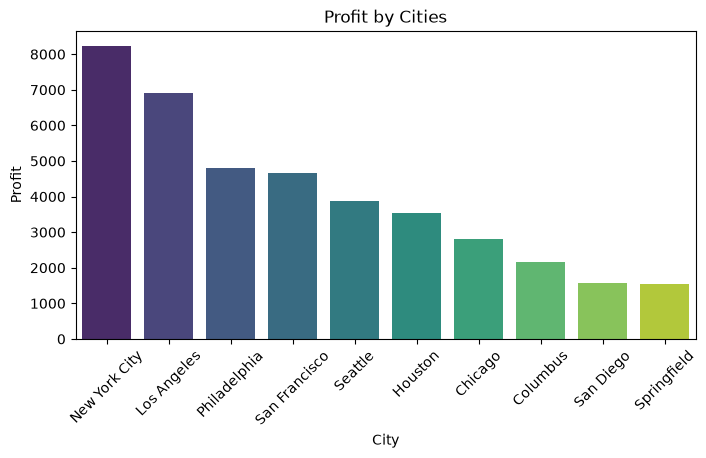

In [26]:
plt.figure(figsize=(8,4))
sns.barplot(top_10_cities, y = top_10_cities['profit'], x= top_10_cities['city'], palette='viridis')

plt.xlabel('City')
plt.ylabel('Profit')
plt.xticks(rotation = 45)
plt.title("Profit by Cities")

In [28]:
location_customer = sales.merge(dim_geography, how='left', left_on='postal_code', right_on='zip')
location_customer[location_customer['lat'].isnull()]['postal_code'].unique()

<ArrowStringArray>
['00M7A', '00T2C', '00M3C', '00V6Z', '00H1A', '00B3H', '00M5H', '00H1B',
 '00H1C', '00M2N', '00T1Y', '00T5A', '00V6G', '00A0A', '00E1A', '00V6B',
 '00V5K', '00G1B', '00C0A', '00V6E', '00R0H', '00S0G', '00R3R']
Length: 23, dtype: str

#### Since we only have ZIP of only US country hence we exclude the customers from Canada since all the ZIP table entries for these would be null

In [30]:
location_customer_us = location_customer[location_customer['country_region'] != 'Canada']
location_customer_us.info()

<class 'pandas.DataFrame'>
Index: 9994 entries, 0 to 10192
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   row_id             9994 non-null   int64         
 1   order_id           9994 non-null   str           
 2   order_date         9994 non-null   datetime64[s] 
 3   ship_date          9994 non-null   object        
 4   ship_mode          9994 non-null   str           
 5   customer_id        9994 non-null   str           
 6   country_region     9994 non-null   str           
 7   city_x             9994 non-null   str           
 8   state_province     9994 non-null   str           
 9   postal_code        9994 non-null   str           
 10  division           9994 non-null   str           
 11  region             9994 non-null   str           
 12  product_id         9994 non-null   str           
 13  sales              9994 non-null   float64       
 14  units              9994

In [34]:
location_customer_us = location_customer_us.merge( dim_factories, how = 'left', on = 'factory_name')

### Haversine distance formula

In [35]:
# Vectorized Haversine distance formula (faster than looping rows)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [37]:
location_customer_us['haversine_distance'] = haversine_distance(location_customer_us['lat'], location_customer_us['lng'],
                                                                    location_customer_us['latitude'], location_customer_us['longitude'])

In [39]:
location_customer_us.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country_region', 'city_x', 'state_province',
       'postal_code', 'division', 'region', 'product_id', 'sales', 'units',
       'gross_profit', 'cost', 'profit_margin_pct', 'product_name',
       'factory_name', 'unit_price', 'unit_cost', 'order_month_year', 'zip',
       'lat', 'lng', 'city_y', 'state_id', 'state_name', 'zcta', 'population',
       'density', 'county_fips', 'county_name', 'county_weights',
       'county_names_all', 'county_fips_all', 'imprecise', 'military',
       'timezone', 'latitude', 'longitude', 'haversine_distance'],
      dtype='str')

In [40]:
sales_by_route = location_customer_us.groupby(['factory_name', 'postal_code', 'city_x', 'state_id']).agg(
    orders = ('order_id', 'nunique'),
    units = ('units', 'sum'),
    revenue = ('sales', 'sum'),
    profit = ('gross_profit', 'sum'),
    cost = ('cost', 'sum'),
    profit_margin = ('profit_margin_pct', 'mean'),
    haversine_distance = ('haversine_distance', 'first') ).reset_index()  # constant within a route, just carry it along

In [41]:
sales_by_route['profit_per_mile'] = sales_by_route['profit']/sales_by_route['haversine_distance']

In [42]:
### keeping the minimum order threshold as 3 to determine efficient routes
sales_by_route_established = sales_by_route[sales_by_route['orders'] >= 3]  # pick your own threshold

In [43]:
sales_by_route_established[sales_by_route['profit_per_mile'] > sales_by_route_established['profit_per_mile'].quantile(.99)].sort_values('profit_per_mile', ascending=False)

C:\Users\omkarkhare\AppData\Local\Temp\ipykernel_11980\971748809.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sales_by_route_established[sales_by_route['profit_per_mile'] > sales_by_route_established['profit_per_mile'].quantile(.99)].sort_values('profit_per_mile', ascending=False)


,factory_name,postal_code,city_x,state_id,orders,units,revenue,profit,cost,profit_margin,haversine_distance,profit_per_mile
457,Lot's O' Nuts,85204,Mesa,AZ,13,77,276.32,190.02,86.30,68.771333,35.585847,5.339763
456,Lot's O' Nuts,85023,Phoenix,AZ,22,70,248.81,173.31,75.50,69.499583,55.125407,3.143922
467,Lot's O' Nuts,85705,Tucson,AZ,13,74,263.65,183.25,80.40,69.344375,61.834363,2.963562
941,Wicked Choccy's,32216,Jacksonville,FL,25,121,417.25,271.63,145.62,65.112188,127.576563,2.129153
462,Lot's O' Nuts,85301,Glendale,AZ,14,43,152.93,106.53,46.40,69.810000,50.803685,2.096895
485,Lot's O' Nuts,90049,Los Angeles,CA,69,322,1146.44,793.44,353.00,69.498554,396.124475,2.003007
459,Lot's O' Nuts,85234,Gilbert,AZ,5,26,92.83,63.23,29.60,69.071429,33.406913,1.892722


In [44]:
sales_by_route_established[sales_by_route['profit_per_mile'] < sales_by_route_established['profit_per_mile'].quantile(.01)].sort_values('profit_per_mile', ascending=False)

C:\Users\omkarkhare\AppData\Local\Temp\ipykernel_11980\3430639391.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sales_by_route_established[sales_by_route['profit_per_mile'] < sales_by_route_established['profit_per_mile'].quantile(.01)].sort_values('profit_per_mile', ascending=False)


,factory_name,postal_code,city_x,state_id,orders,units,revenue,profit,cost,profit_margin,haversine_distance,profit_per_mile
1302,Wicked Choccy's,94533,Fairfield,CA,3,7,25.25,16.47,8.78,65.2275,2330.945572,0.007066
713,Sugar Shack,10011,New York City,NY,4,10,16.47,8.22,8.25,52.8225,1201.563458,0.006841
754,The Other Factory,22153,Springfield,VA,3,13,42.25,3.25,39.00,7.6900,745.967083,0.004357
749,The Other Factory,19134,Philadelphia,PA,3,13,42.25,3.25,39.00,7.6900,879.565136,0.003695
743,The Other Factory,10009,New York City,NY,3,11,35.75,2.75,33.00,7.6900,952.053072,0.002888
746,The Other Factory,10035,New York City,NY,3,7,22.75,1.75,21.00,7.6900,956.028082,0.001830
797,The Other Factory,94122,San Francisco,CA,4,12,39.00,3.00,36.00,7.6900,1807.360653,0.001660


In [46]:
orders_us = location_customer_us[['order_id', 'product_name', 'division', 'factory_name',
                                     'units', 'sales', 'gross_profit',
                                     'lat', 'lng', 'haversine_distance']].copy()

In [48]:
orders_all_factories = orders_us.merge(dim_factories, how='cross')

In [50]:
orders_all_factories['haversine_distance_facories'] = haversine_distance(orders_all_factories['lat'], orders_all_factories['lng'],
                                                                            orders_all_factories['latitude'], orders_all_factories['longitude'])

In [51]:
required_factories = orders_all_factories[orders_all_factories['haversine_distance_facories'] < orders_all_factories['haversine_distance']]
required_factories

,order_id,product_name,division,factory_name_x,units,sales,gross_profit,lat,lng,haversine_distance,factory_name_y,latitude,longitude,haversine_distance_facories
1,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,Wicked Choccy's,2,6.50,4.22,29.90834,-95.65492,874.966612,Secret Factory,41.446333,-90.565487,846.411940
3,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,Wicked Choccy's,2,6.50,4.22,29.90834,-95.65492,874.966612,The Other Factory,35.117500,-89.971107,488.898842
6,US-2021-112326-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,2,7.50,4.90,41.76361,-88.14476,773.893403,Secret Factory,41.446333,-90.565487,126.967711
7,US-2021-112326-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,2,7.50,4.90,41.76361,-88.14476,773.893403,Sugar Shack,48.119140,-96.181150,588.687133
8,US-2021-112326-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,2,7.50,4.90,41.76361,-88.14476,773.893403,The Other Factory,35.117500,-89.971107,469.689358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49944,US-2024-126221-CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,Lot's O' Nuts,2,6.98,4.98,39.15074,-85.99432,1498.263521,Wicked Choccy's,32.076176,-81.088371,560.905370
49945,US-2024-115427-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,2,7.50,4.90,38.28132,-122.00693,2330.945572,Lot's O' Nuts,32.881893,-111.768036,685.052135
49946,US-2024-115427-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,2,7.50,4.90,38.28132,-122.00693,2330.945572,Secret Factory,41.446333,-90.565487,1672.445787
49947,US-2024-115427-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,2,7.50,4.90,38.28132,-122.00693,2330.945572,Sugar Shack,48.119140,-96.181150,1457.860290


In [54]:
alt_factories  = required_factories.groupby(['order_id', 'product_name', 'factory_name_x']).agg(   
    units = ('units', 'first')
    ,sales = ('sales', 'first')
    , profit = ('gross_profit', 'first'),
    alt_haversine_distance = ('haversine_distance_facories', 'min') ).reset_index()  # constant within a route, just carry it along

In [55]:
idx = required_factories.groupby(['order_id', 'product_name'])['haversine_distance_facories'].idxmin()

## get the idx rows 'Order ID', 'Product Name', 'Factory_y', 'haversine_distance_facories'
alt_factories = required_factories.loc[idx, ['order_id', 'product_name', 'factory_name_x', 'factory_name_y', 'haversine_distance_facories']]

### rename the columns
alt_factories = alt_factories.rename(columns={'factory_name_x' : 'actual_factory', 'factory_name_y': 'best_alt_factory', 
                                               'haversine_distance_facories': 'alt_haversine_distance'})

In [61]:
# Fix a candidate factory, sum volume-weighted distance across ALL of a product's orders
product_factory_cost = (orders_all_factories
    .assign(weighted = orders_all_factories['haversine_distance_facories'] * orders_all_factories['units'])
    .groupby(['product_name', 'factory_name_y'])['weighted']
    .sum()
    .unstack())   # columns = candidate factories, rows = products

current_factory = orders_us.groupby('product_name')['factory_name'].first()
current_cost = (orders_us.assign(weighted = orders_us['haversine_distance'] * orders_us['units'])
                          .groupby('product_name')['weighted'].sum())

comparison = pd.DataFrame({'current_factory': current_factory, 'current_cost': current_cost})
comparison['best_factory']  = product_factory_cost.idxmin(axis=1)
comparison['best_cost']     = product_factory_cost.min(axis=1)
comparison['savings_pct']   = round((comparison['current_cost'] - comparison['best_cost'])
                                     / comparison['current_cost'] * 100, 1)

candidates = comparison[comparison['current_factory'] != comparison['best_factory']]
candidates.reset_index().sort_values('savings_pct')

,product_name,current_factory,current_cost,best_factory,best_cost,savings_pct
11,Wonka Gum,Secret Factory,3.836984e+05,The Other Factory,3.774230e+05,1.6
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,9.272431e+06,Secret Factory,7.625548e+06,17.8
2,Hair Toffee,The Other Factory,2.016443e+04,Lot's O' Nuts,1.648949e+04,18.2
9,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,8.878833e+06,Secret Factory,7.162169e+06,19.3
0,Everlasting Gobstopper,Secret Factory,1.050403e+04,The Other Factory,8.279014e+03,21.2
5,SweeTARTS,Sugar Shack,4.404703e+04,Secret Factory,3.171150e+04,28.0
6,Wonka Bar - Fudge Mallows,Lot's O' Nuts,8.979884e+06,Secret Factory,6.435308e+06,28.3
10,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,9.987021e+06,Secret Factory,7.141426e+06,28.5
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,8.783053e+06,Secret Factory,6.175292e+06,29.7
4,Nerds,Sugar Shack,1.199171e+04,Wicked Choccy's,7.106721e+03,40.7


In [60]:
orders_all_factories['weighted'] = orders_all_factories['haversine_distance_facories'] * orders_all_factories['units']

product_factory_cost = orders_all_factories.groupby(['product_name', 'factory_name_y'])['weighted'].sum().unstack()

current_factory = orders_us.groupby('product_name')['factory_name'].first()
orders_us['weighted'] = orders_us['haversine_distance'] * orders_us['units']
current_cost = orders_us.groupby('product_name')['weighted'].sum()

comparison = pd.DataFrame({'current_factory': current_factory, 'current_cost': current_cost})
comparison['best_factory']  = product_factory_cost.idxmin(axis=1)
comparison['best_cost']     = product_factory_cost.min(axis=1)
comparison['savings_pct']   = round((comparison['current_cost'] - comparison['best_cost'])
                                     / comparison['current_cost'] * 100, 1)

candidates = comparison[comparison['current_factory'] != comparison['best_factory']]
candidates.reset_index().sort_values('savings_pct', ascending=False)

,product_name,current_factory,current_cost,best_factory,best_cost,savings_pct
3,Laffy Taffy,Sugar Shack,3.437299e+04,Wicked Choccy's,1.594389e+04,53.6
1,Fun Dip,Sugar Shack,7.667897e+03,Secret Factory,4.430979e+03,42.2
4,Nerds,Sugar Shack,1.199171e+04,Wicked Choccy's,7.106721e+03,40.7
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,8.783053e+06,Secret Factory,6.175292e+06,29.7
10,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,9.987021e+06,Secret Factory,7.141426e+06,28.5
6,Wonka Bar - Fudge Mallows,Lot's O' Nuts,8.979884e+06,Secret Factory,6.435308e+06,28.3
5,SweeTARTS,Sugar Shack,4.404703e+04,Secret Factory,3.171150e+04,28.0
0,Everlasting Gobstopper,Secret Factory,1.050403e+04,The Other Factory,8.279014e+03,21.2
9,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,8.878833e+06,Secret Factory,7.162169e+06,19.3
2,Hair Toffee,The Other Factory,2.016443e+04,Lot's O' Nuts,1.648949e+04,18.2
